# **Healthcare Analytics Notebook**

**Problem:** Analyze patient outcomes and identify factors affecting hospital **readmissions**



---



## **1. Understanding the data**

## **About Dataset**

*[Kagggle data card ](https://www.kaggle.com/datasets/brandao/diabetes/data):*

It is important to know if a patient will be readmitted in some hospital. The reason is that you can change the treatment, in order to avoid a readmission.

In this database, you have 3 different outputs:

1. No readmission;
2. A readmission in less than 30 days (this situation is not good, because maybe your treatment was not appropriate);
3. A readmission in more than 30 days (this one is not so good as well the last one, however, the reason can be the state of the patient.

In this context, you can see different objective functions for the problem. You can try to figure out situations where the patient will not be readmitted, or if their are going to be readmitted in less than 30 days (because the problem can the the treatment), etc… Make your choice and let's help them creating new approaches for the problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import chi2

# Deactivate warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [2]:
df = pd.read_csv('/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.describe().astype(float).round(2)

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00




---



### **Data Review**

On this section we will revie the healthcare dataset to undestand more about the data such as:

1. Describe the data for mininful insigths
2. Data Types to make sure the data types is relevant to the data description
3. Missing Data review
4. Data scale review

All of this information is imperative for Data Preprocessing.


### Dimensional Tables

You can review the original data source [here](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

There are some categorical features that does not containg the meaining of each category directly on the original file. However this site shared the file **IDS_mapping.cvs** containing the mapping for the following categorical variables:

1. admission_type_id
2. discharge_disposition_id
3. admission_source_id

In [4]:
# read the dimensional information

dims_df = pd.read_csv('/IDS_mapping.csv')
dims_df.head(10)

,Feature,Value,Description
0,admission_type_id,1,Emergency
1,admission_type_id,2,Urgent
2,admission_type_id,3,Elective
3,admission_type_id,4,Newborn
4,admission_type_id,5,Not Available
5,admission_type_id,6,NaN
6,admission_type_id,7,Trauma Center
7,admission_type_id,8,Not Mapped
8,discharge_disposition_id,1,Discharged to home
9,discharge_disposition_id,2,Discharged/transferred to another short term h...


#### Traget Column: readmitted
Contains Values:

1. NO = No readmission
2. \>30 = Readmitted after 30 days
3. \<30 = Readmitted before 30 days

In [5]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

<Axes: ylabel='readmitted'>

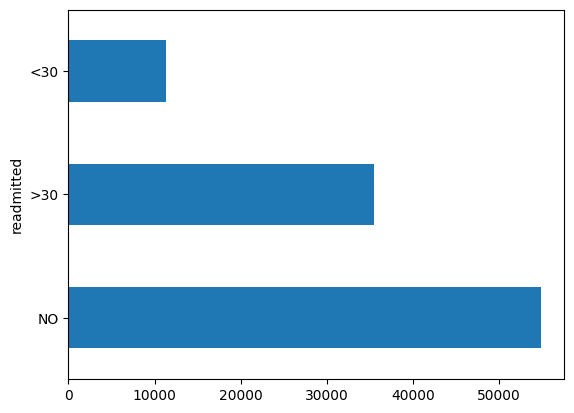

In [6]:
# Plot Readmitted column
y.value_counts().plot(kind='barh')


#### Data Types

Review of data types for both diabetes df and the dimensional df

Also, quick review for null counts

In [7]:
# Quick review of data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
# Quick review to dimensional dataset
dims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Feature      63 non-null     object
 1   Value        63 non-null     int64 
 2   Description  60 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB




#### **Conclusion of this section**


The 50 features from the Diabetes dataset are devided on three groups:

1. Patient personal and stay information
2. Patient med history
3. Target feature: **Readmitted**

Next actions:

1. Adjust the ID columns that will join the dimentional dataset
2. Data Cleaning and Preprocessing


---





## **2. Data Visulization**

On this section we will review the features before data cleaning and preprocessing.

The idea is to get insights about each feature:

1. Data Distribution
2. Detect Patterns Visualy
3. Identify Data Quality Issues

### Dependent Feature (Reamitted)



> Days to inpatient readmission. Values: **\<30** if the patient was readmitted in less than 30 days, **>30** if the patient was readmitted in more than 30 days, and **No** for no record of readmission.



<Axes: ylabel='readmitted'>

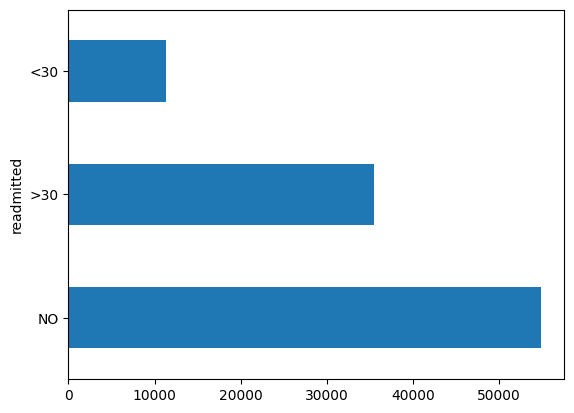

In [9]:
# Plot Readmitted column
y.value_counts().plot(kind='barh')


### Review percentage of Readmitted counts

In [10]:
y_group = y.value_counts(normalize=True)
y_group

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


### Review percentage of Readmitted counts by Race, Gender, Age & Weight

Group By Race

In [11]:
y_race_readmitted = df[df['readmitted'] != 'NO'].groupby(['race']).size().reset_index(name='Readmitted_Count')
y_race_total = df.groupby(['race']).size().reset_index(name='Total_Population')

# Merge the two dataframes
race_comparison = pd.merge(y_race_readmitted, y_race_total, on='race', how='outer').fillna(0)

# Calculate the percentage of readmitted patients out of the total population
race_comparison['Readmitted_Percentage_of_Total'] = (race_comparison['Readmitted_Count'] / race_comparison['Total_Population'])

race_comparison.sort_values(by='Readmitted_Percentage_of_Total', ascending=False)

,race,Readmitted_Count,Total_Population,Readmitted_Percentage_of_Total
3,Caucasian,35716,76099,0.469336
1,AfricanAmerican,8789,19210,0.457522
4,Hispanic,854,2037,0.419244
5,Other,591,1506,0.392430
2,Asian,226,641,0.352574
0,?,726,2273,0.319402


Group By Gender

In [12]:
y_gender_readmitted = df[df['readmitted'] != 'NO'].groupby(['gender']).size().reset_index(name='Readmitted_Count')
y_gender_total = df.groupby(['gender']).size().reset_index(name='Total_Population')

# Merge the two dataframes
gender_comparison = pd.merge(y_gender_readmitted, y_gender_total, on='gender', how='outer').fillna(0)

# Calculate the percentage of readmitted patients out of the total population
gender_comparison['Readmitted_Percentage_of_Total'] = (gender_comparison['Readmitted_Count'] / gender_comparison['Total_Population'])

gender_comparison.sort_values(by='Readmitted_Percentage_of_Total', ascending=False)

,gender,Readmitted_Count,Total_Population,Readmitted_Percentage_of_Total
0,Female,25670.0,54708,0.469218
1,Male,21232.0,47055,0.451217
2,Unknown/Invalid,0.0,3,0.000000


Group By Age Group

In [13]:
y_age_readmitted = df[df['readmitted'] != 'NO'].groupby(['age']).size().reset_index(name='Readmitted_Count')
y_age_total = df.groupby(['age']).size().reset_index(name='Total_Population')

# Merge the two dataframes
age_comparison = pd.merge(y_age_readmitted, y_age_total, on='age', how='outer').fillna(0)

# Calculate the percentage of readmitted patients out of the total population
age_comparison['Readmitted_Percentage_of_Total'] = (age_comparison['Readmitted_Count'] / age_comparison['Total_Population'])

age_comparison.sort_values(by='Readmitted_Percentage_of_Total', ascending=False)

,age,Readmitted_Count,Total_Population,Readmitted_Percentage_of_Total
8,[80-90),8301,17197,0.482700
7,[70-80),12544,26068,0.481203
6,[60-70),10399,22483,0.462527
2,[20-30),746,1657,0.450211
4,[40-50),4305,9685,0.444502
5,[50-60),7585,17256,0.439557
3,[30-40),1611,3775,0.426755
9,[90-100),1118,2793,0.400286
1,[10-20),264,691,0.382055
0,[0-10),29,161,0.180124


Group By Weigth Group

In [14]:
y_weight_readmitted = df[df['readmitted'] != 'NO'].groupby(['weight']).size().reset_index(name='Readmitted_Count')
y_weight_total = df.groupby(['weight']).size().reset_index(name='Total_Population')

# Merge the two dataframes
weight_comparison = pd.merge(y_weight_readmitted, y_weight_total, on='weight', how='outer').fillna(0)

# Calculate the percentage of readmitted patients out of the total population
weight_comparison['Readmitted_Percentage_of_Total'] = (weight_comparison['Readmitted_Count'] / weight_comparison['Total_Population'])

weight_comparison.sort_values(by='Readmitted_Percentage_of_Total', ascending=False)

,weight,Readmitted_Count,Total_Population,Readmitted_Percentage_of_Total
0,>200,3,3,1.000000
2,[0-25),39,48,0.812500
9,[75-100),816,1336,0.610778
3,[100-125),359,625,0.574400
4,[125-150),81,145,0.558621
8,[50-75),494,897,0.550725
6,[175-200),6,11,0.545455
5,[150-175),19,35,0.542857
7,[25-50),50,97,0.515464
1,?,45035,98569,0.456888




#### **Conclusion of Vizualisation of Readmitted (Dependent Feature)**


Exporing the distribution of the Readmitted feature we found interesting insights:

1. More than 50 percent of the pattient on the dataset were not readmitted.
2. Around 30% of the pattients on the dataset were readmitted after 30 days.
3. Around 11% of the pattients on the dataset were readmitted before 30 days.
4. The Race with highest rate of readmission is **Caucasian**, with **46%** of readmission, the lower is **"?"** (Unknown) with **31%**.
5. The Gender with highest rate of readmission is **Female**, with **46%** of readmission, the lower is **Unknown/Invalid** with **0%**.
6. The Age group with highest rate of readmission is **60-70 years**, with **46%** of readmission, the lower is **0-10 years** with **18%**.
7. The Weight group with highest rate of readmission is **\>200 pounds**, with **46%** of readmission, the lower is **?** (Unknown) with **45%**.

Next actions:

1. Data Cleaning and Preprocessing: The weight group **?** represend a good amount of data of the entire dataset. Therefore, this should be treated as NULL values for correct preprocessing.
2. Data Visualization for the rest of the Independent variables's distribution exploration
---





### Independent Features



> Steps applied:
> 1. Correct the dimensional keys to string datatype
> 2. Change IDs to Categories from Dimensional datset
> 3. Plot Numerical features for Distribution exploration
> 4. Plot Categorical features for Distribution exploration




> 1. Correct the dimensional keys to string datatype

In [15]:
# Convert ids to string dtype

ids = ['admission_type_id', 'discharge_disposition_id','admission_source_id']
df[ids] = df[ids].astype('string')

dims_df['Value'] = dims_df['Value'].astype('string')

print(df[ids].info())
print(dims_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   admission_type_id         101766 non-null  string
 1   discharge_disposition_id  101766 non-null  string
 2   admission_source_id       101766 non-null  string
dtypes: string(3)
memory usage: 2.3 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Feature      63 non-null     object
 1   Value        63 non-null     string
 2   Description  60 non-null     object
dtypes: object(2), string(1)
memory usage: 1.6+ KB
None


> 2. Change IDs to Categories from Dimensional datset

In [16]:
# Join df with the dims_df dataset to add the Description column from dims_df
new_cols = []

for id in ids:
  # Lookup to the dimensional df, using the df[ids] and dims feature and value
  df[id + '_desc'] = df[id].map(dims_df[dims_df['Feature'] == id].set_index('Value')['Description'])
  new_cols = new_cols + [id + '_desc']

df[new_cols].head()

,admission_type_id_desc,discharge_disposition_id_desc,admission_source_id_desc
0,NaN,Not Mapped,Physician Referral
1,Emergency,Discharged to home,Emergency Room
2,Emergency,Discharged to home,Emergency Room
3,Emergency,Discharged to home,Emergency Room
4,Emergency,Discharged to home,Emergency Room


> 3. Plot Numerical features for Distribution exploration

In [17]:
# Select numerical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns

# Drop ids
num_features = num_features.drop(['encounter_id', 'patient_nbr'])
num_features

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object')

In [18]:
# Display descriptive information in integer values
df[df['readmitted'] != 'NO'][num_features].describe().astype(float).round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,46902.00,46902.00,46902.00,46902.00,46902.00,46902.00,46902.00,46902.00
mean,4.56,43.93,1.26,16.43,0.48,0.30,0.93,7.66
std,3.00,19.50,1.66,7.74,1.49,1.24,1.56,1.80
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,33.00,0.00,11.00,0.00,0.00,0.00,6.00
50%,4.00,45.00,1.00,15.00,0.00,0.00,0.00,9.00
75%,6.00,58.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


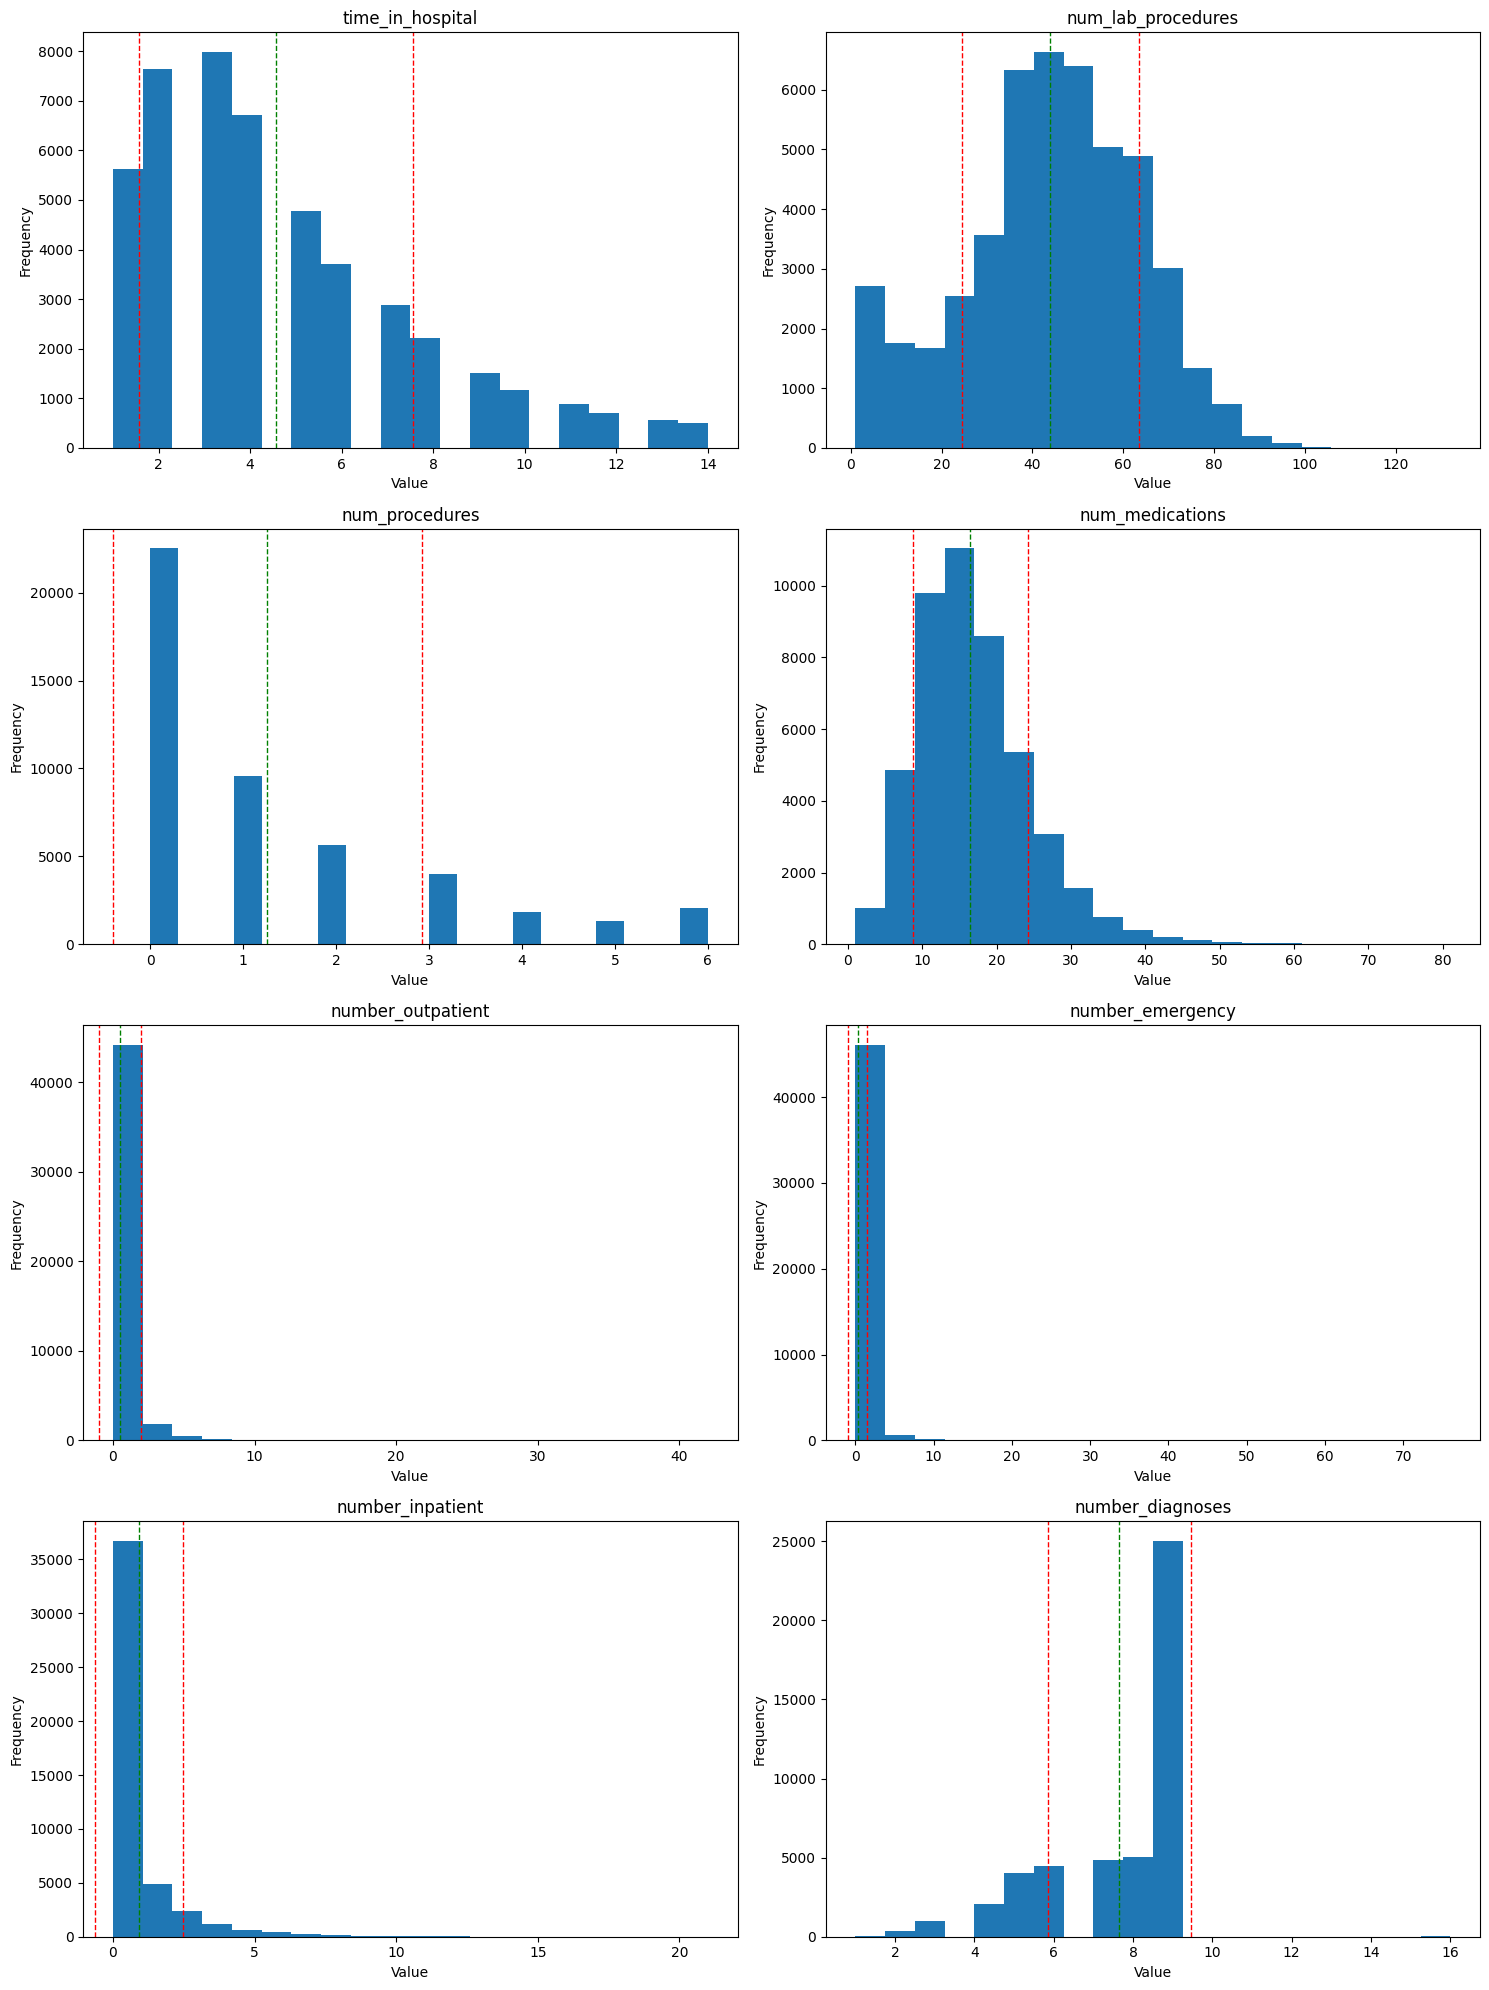

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for i, ax in enumerate(axes.flatten()):
    ax.hist(df[df['readmitted'] != 'NO'][num_features[i]], bins=20)
    # add average and standard deviation dotted lines
    ax.axvline(df[df['readmitted'] != 'NO'][num_features[i]].mean(), color='g', linestyle='dashed', linewidth=1)
    ax.axvline(df[df['readmitted'] != 'NO'][num_features[i]].mean() - df[df['readmitted'] != 'NO'][num_features[i]].std(), color='r', linestyle='dashed', linewidth=1)
    ax.axvline(df[df['readmitted'] != 'NO'][num_features[i]].mean() + df[df['readmitted'] != 'NO'][num_features[i]].std(), color='r', linestyle='dashed', linewidth=1)
    ax.set_title(num_features[i])
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()

> 4. Plot Categorical features for Distribution exploration

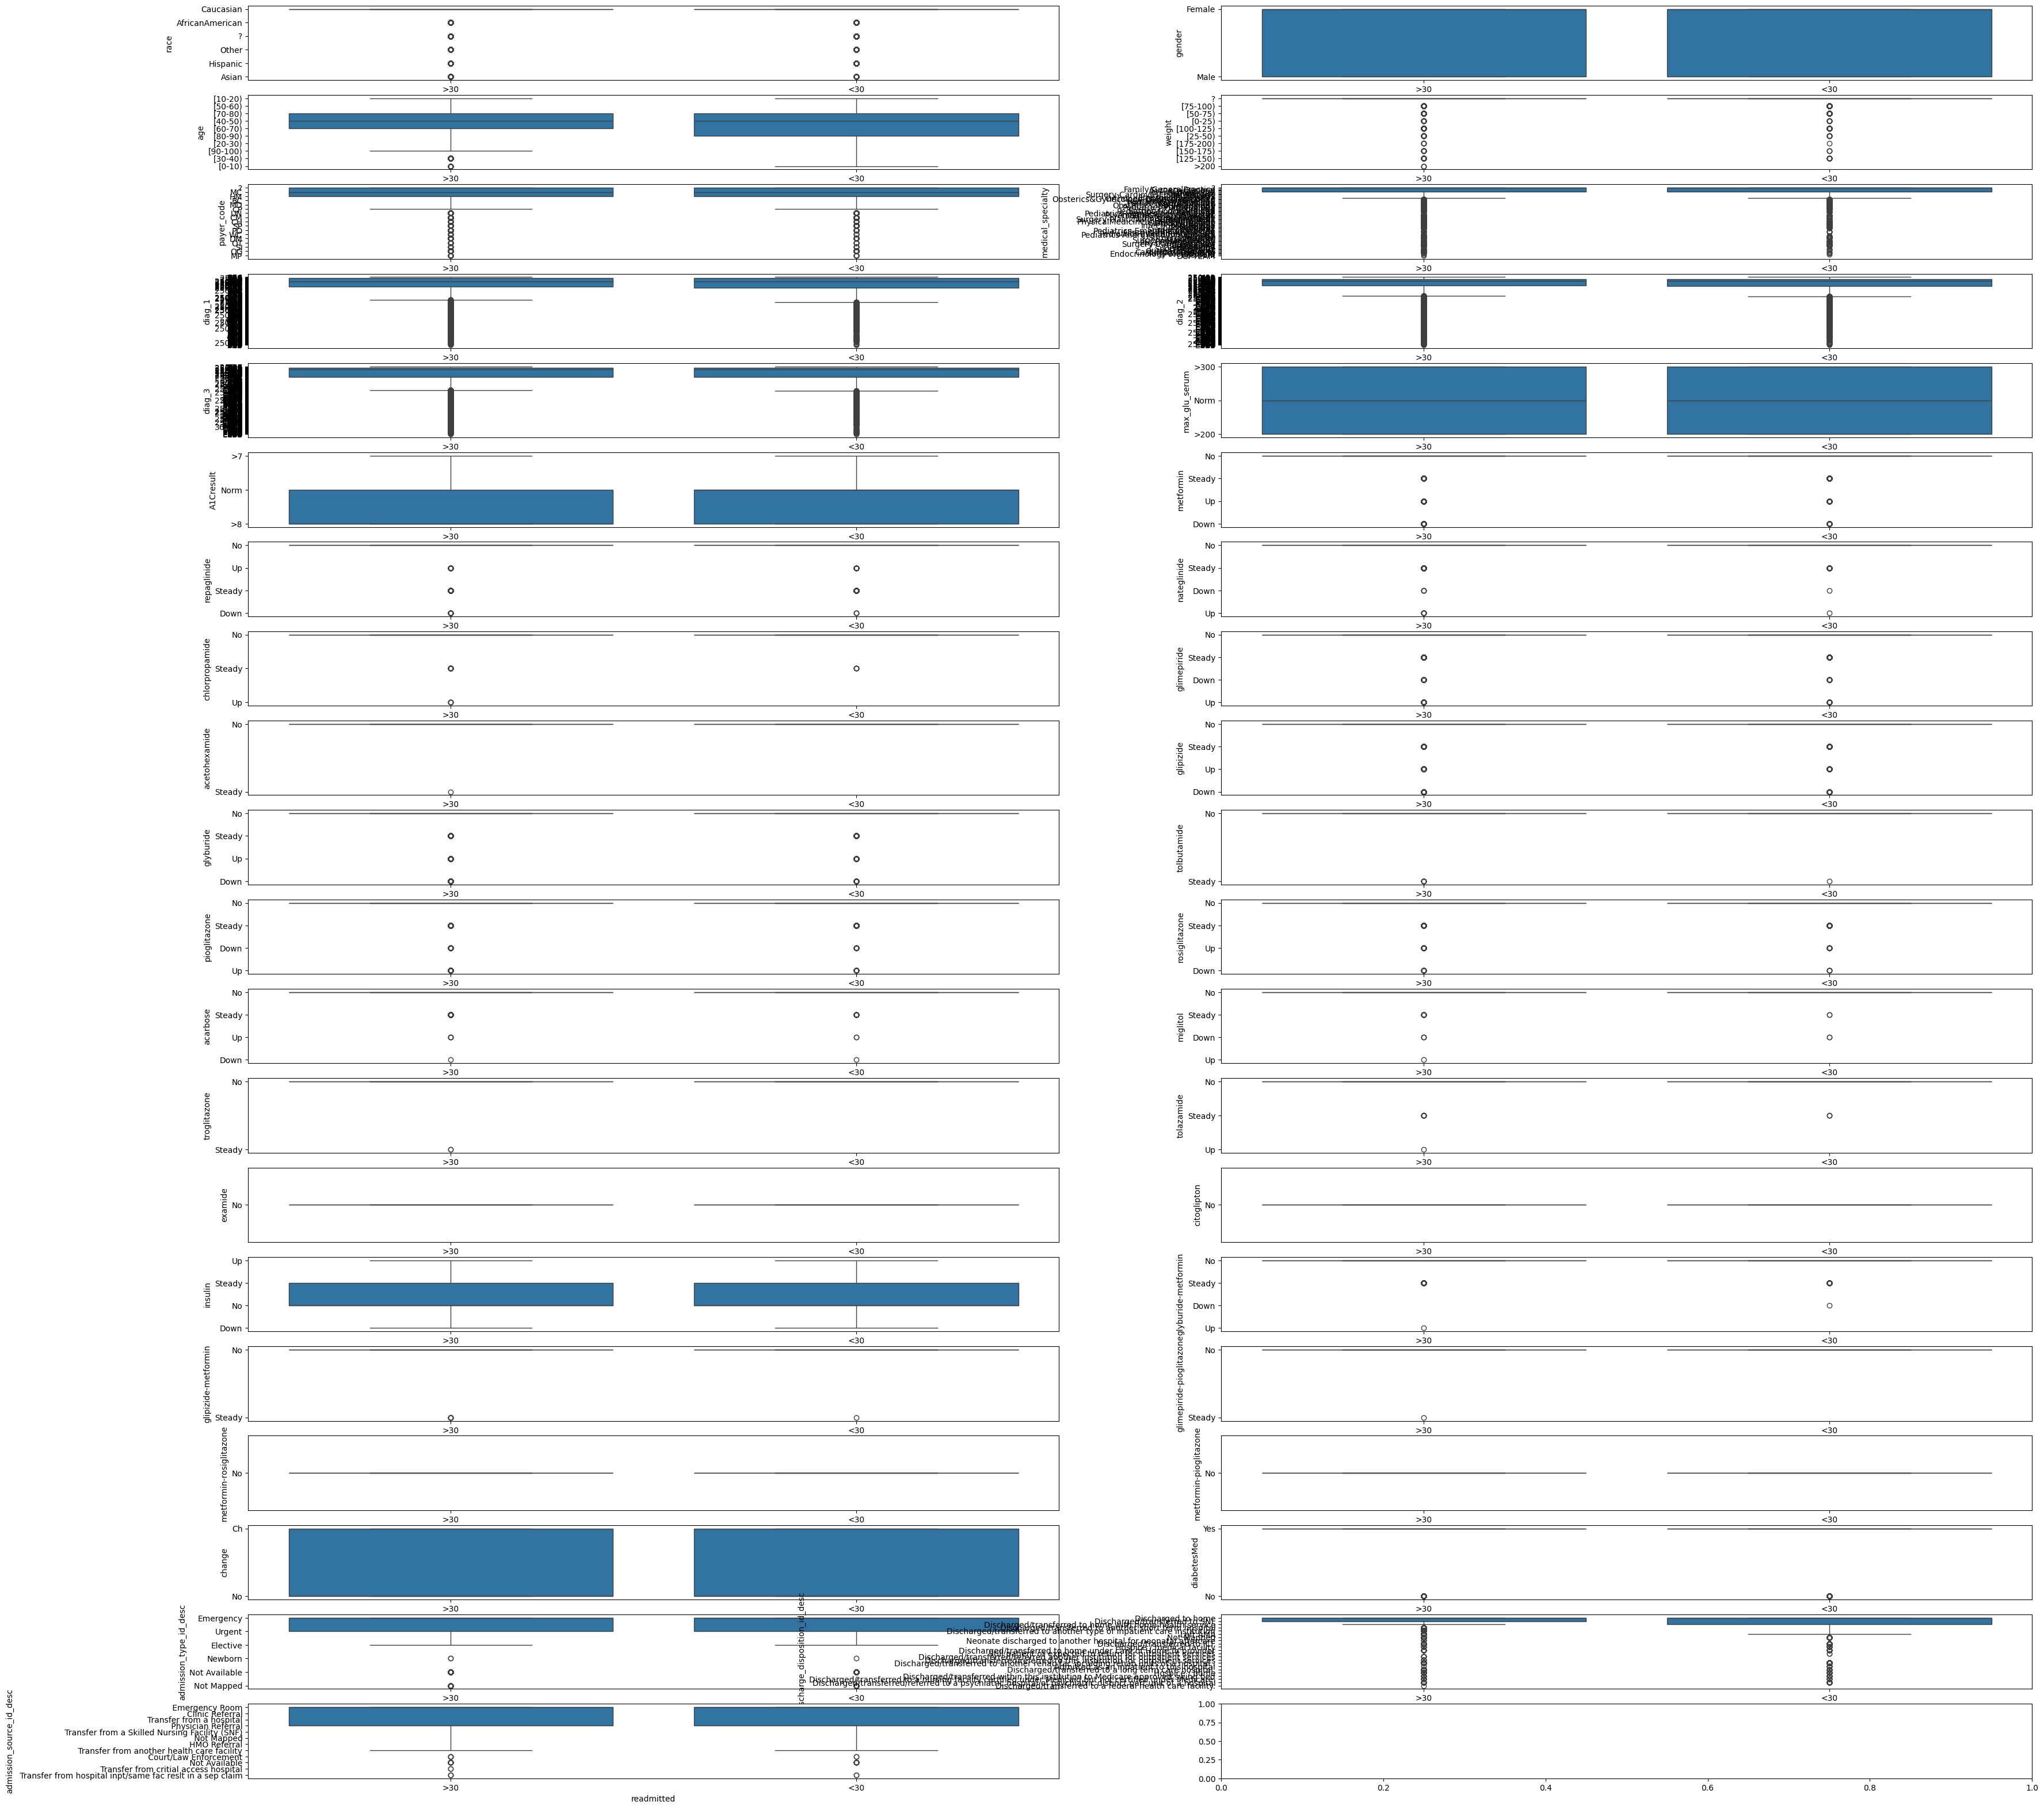

In [20]:
# Boxplot grid for categorical features

categorical_features = df.select_dtypes(include=['object']).columns
categorical_features = categorical_features.drop('readmitted') # Assign the result back

# Dynamically calculate rows and columns for subplots
num_features = len(categorical_features)
ncols = 2
nrows = (num_features + ncols - 1) // ncols # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(40, 40))

for feature, ax in zip(categorical_features, axes.flatten()):
    sns.boxplot(x='readmitted', y=feature, data=df[df['readmitted'] != 'NO'], ax=ax)

plt.show()


In [21]:
df[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   race                           101766 non-null  object
 1   gender                         101766 non-null  object
 2   age                            101766 non-null  object
 3   weight                         101766 non-null  object
 4   payer_code                     101766 non-null  object
 5   medical_specialty              101766 non-null  object
 6   diag_1                         101766 non-null  object
 7   diag_2                         101766 non-null  object
 8   diag_3                         101766 non-null  object
 9   max_glu_serum                  5346 non-null    object
 10  A1Cresult                      17018 non-null   object
 11  metformin                      101766 non-null  object
 12  repaglinide                    101766 non-nu



#### **Conclusion of Vizualisation of Independent Feature**


Exporing the distribution of the Independent features we found interesting insights:

**Numerical Features**
1. The time in days that the patients stayed at the hospital in average is 4.56
2. Number of Lab procedures is 43.93 in averge.
3. Number of procedure in average is 1.25
4. Number of medication in average is 16.43
5. Number of Outpatioent and Inpatient are similar in average, 0.48 and .93 respectively.

**Categorical Features**
1. For categorical features is recommended to compare dependency agains the Y Feature "readmitted" as the distributions in most of the categorical features is not clear.
2. The group Age 40-50 years are the average readmitted patiens, for both aftes or before 30 days of last stay in the hospital

Next actions:

1. Data Cleaning and Preprocessing: NUll values
2. Explore the feature dependency
---





## **3. Data Cleaning & Preprocessing**

On this section we will clean the data and preprocess for better performance compute.

Activities on this section:

1. Missing Values
2. Outliers
4. Feature Scaling

#### Handleling Missing Values

In [22]:
# Inspect null values
missing_val = df.columns[df.isnull().any()]
missing_val

Index(['max_glu_serum', 'A1Cresult', 'admission_type_id_desc',
       'discharge_disposition_id_desc', 'admission_source_id_desc'],
      dtype='object')

In [23]:
# Find how many missing values we have per feature
df[missing_val].isnull().sum().sort_values(ascending=False)

,0
max_glu_serum,96420
A1Cresult,84748
admission_source_id_desc,6781
admission_type_id_desc,5291
discharge_disposition_id_desc,3691


In [24]:
# See data types for features with missing values
df[missing_val].dtypes

,0
max_glu_serum,object
A1Cresult,object
admission_type_id_desc,object
discharge_disposition_id_desc,object
admission_source_id_desc,object


***Actions on missing values***

1. Feature max_glu_serum, per the dataset documentation: *Indicates the range of the result or if the test was not taken. Values: >200, >300, normal, and none if not measured*, Strategy: Replace null values with ***Not Measured***
2. Feature A1Cresult, per the dataset documentation: *>8 if the result was greater than 8%, >7 if the result was greater than 7% but less than 8%, normal if the result was less than 7%, and none if not measured.*. Strategy: Replace null with ***Not Measured***
3. For the 3 features from the DIM table: admission_type_id_desc, discharge_disposition_id_desc, admission_source_id_desc. Strategy: As the DIM also contains the value ***Not Mapped*** and the total missing values are not a critical amount we can safetly remapped and not miss the records.

Replace max_glu_serum and A1Cresult with "Not Measured"

In [25]:
# Repalce null

df[['max_glu_serum', 'A1Cresult']] = df[['max_glu_serum', 'A1Cresult']].fillna('Not Measured')

Repalce dimensional null descriptions with "***Not Mapped***"

In [26]:
df[['admission_type_id_desc', 'discharge_disposition_id_desc', 'admission_source_id_desc']] = df[['admission_type_id_desc', 'discharge_disposition_id_desc', 'admission_source_id_desc']].fillna('Not Mapped')

In [27]:
# Inspect null values
missing_val = df.columns[df.isnull().any()]
missing_val

Index([], dtype='object')

#### Outliers Detection & Handleling

For this project, we chose to detect outliers with Standard Deviation.

In [28]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features

Index(['encounter_id', 'patient_nbr', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses'],
      dtype='object')

In [29]:
# Numerical features were already stored in a variable
#
# We can now define the limits using +/- 3 sigmas per variable

limit_sigma = {}

for num in num_features:
 limit_sigma[num] = df[num].mean() - 3 * df[num].std(), df[num].mean() + 3 * df[num].std()


limit_sigma

{'encounter_id': (np.float64(-142719242.32739478),
  np.float64(473122533.5733512)),
 'patient_nbr': (np.float64(-61758677.34465582),
  np.float64(170419478.7345503)),
 'time_in_hospital': (np.float64(-4.559336430568455),
  np.float64(13.351310174254952)),
 'num_lab_procedures': (np.float64(-15.927445767139574),
  np.float64(102.1187277277158)),
 'num_procedures': (np.float64(-3.7776905755524615),
  np.float64(6.457151299173318)),
 'num_medications': (np.float64(-8.360854396615892),
  np.float64(40.40454285838112)),
 'number_outpatient': (np.float64(-3.432438136914),
  np.float64(4.171152442281215)),
 'number_emergency': (np.float64(-2.59358059277945),
  np.float64(2.989253017754393)),
 'number_inpatient': (np.float64(-3.1530239641931748),
  np.float64(4.4241557763897825)),
 'number_diagnoses': (np.float64(1.6218063295447438),
  np.float64(13.223407199531763))}

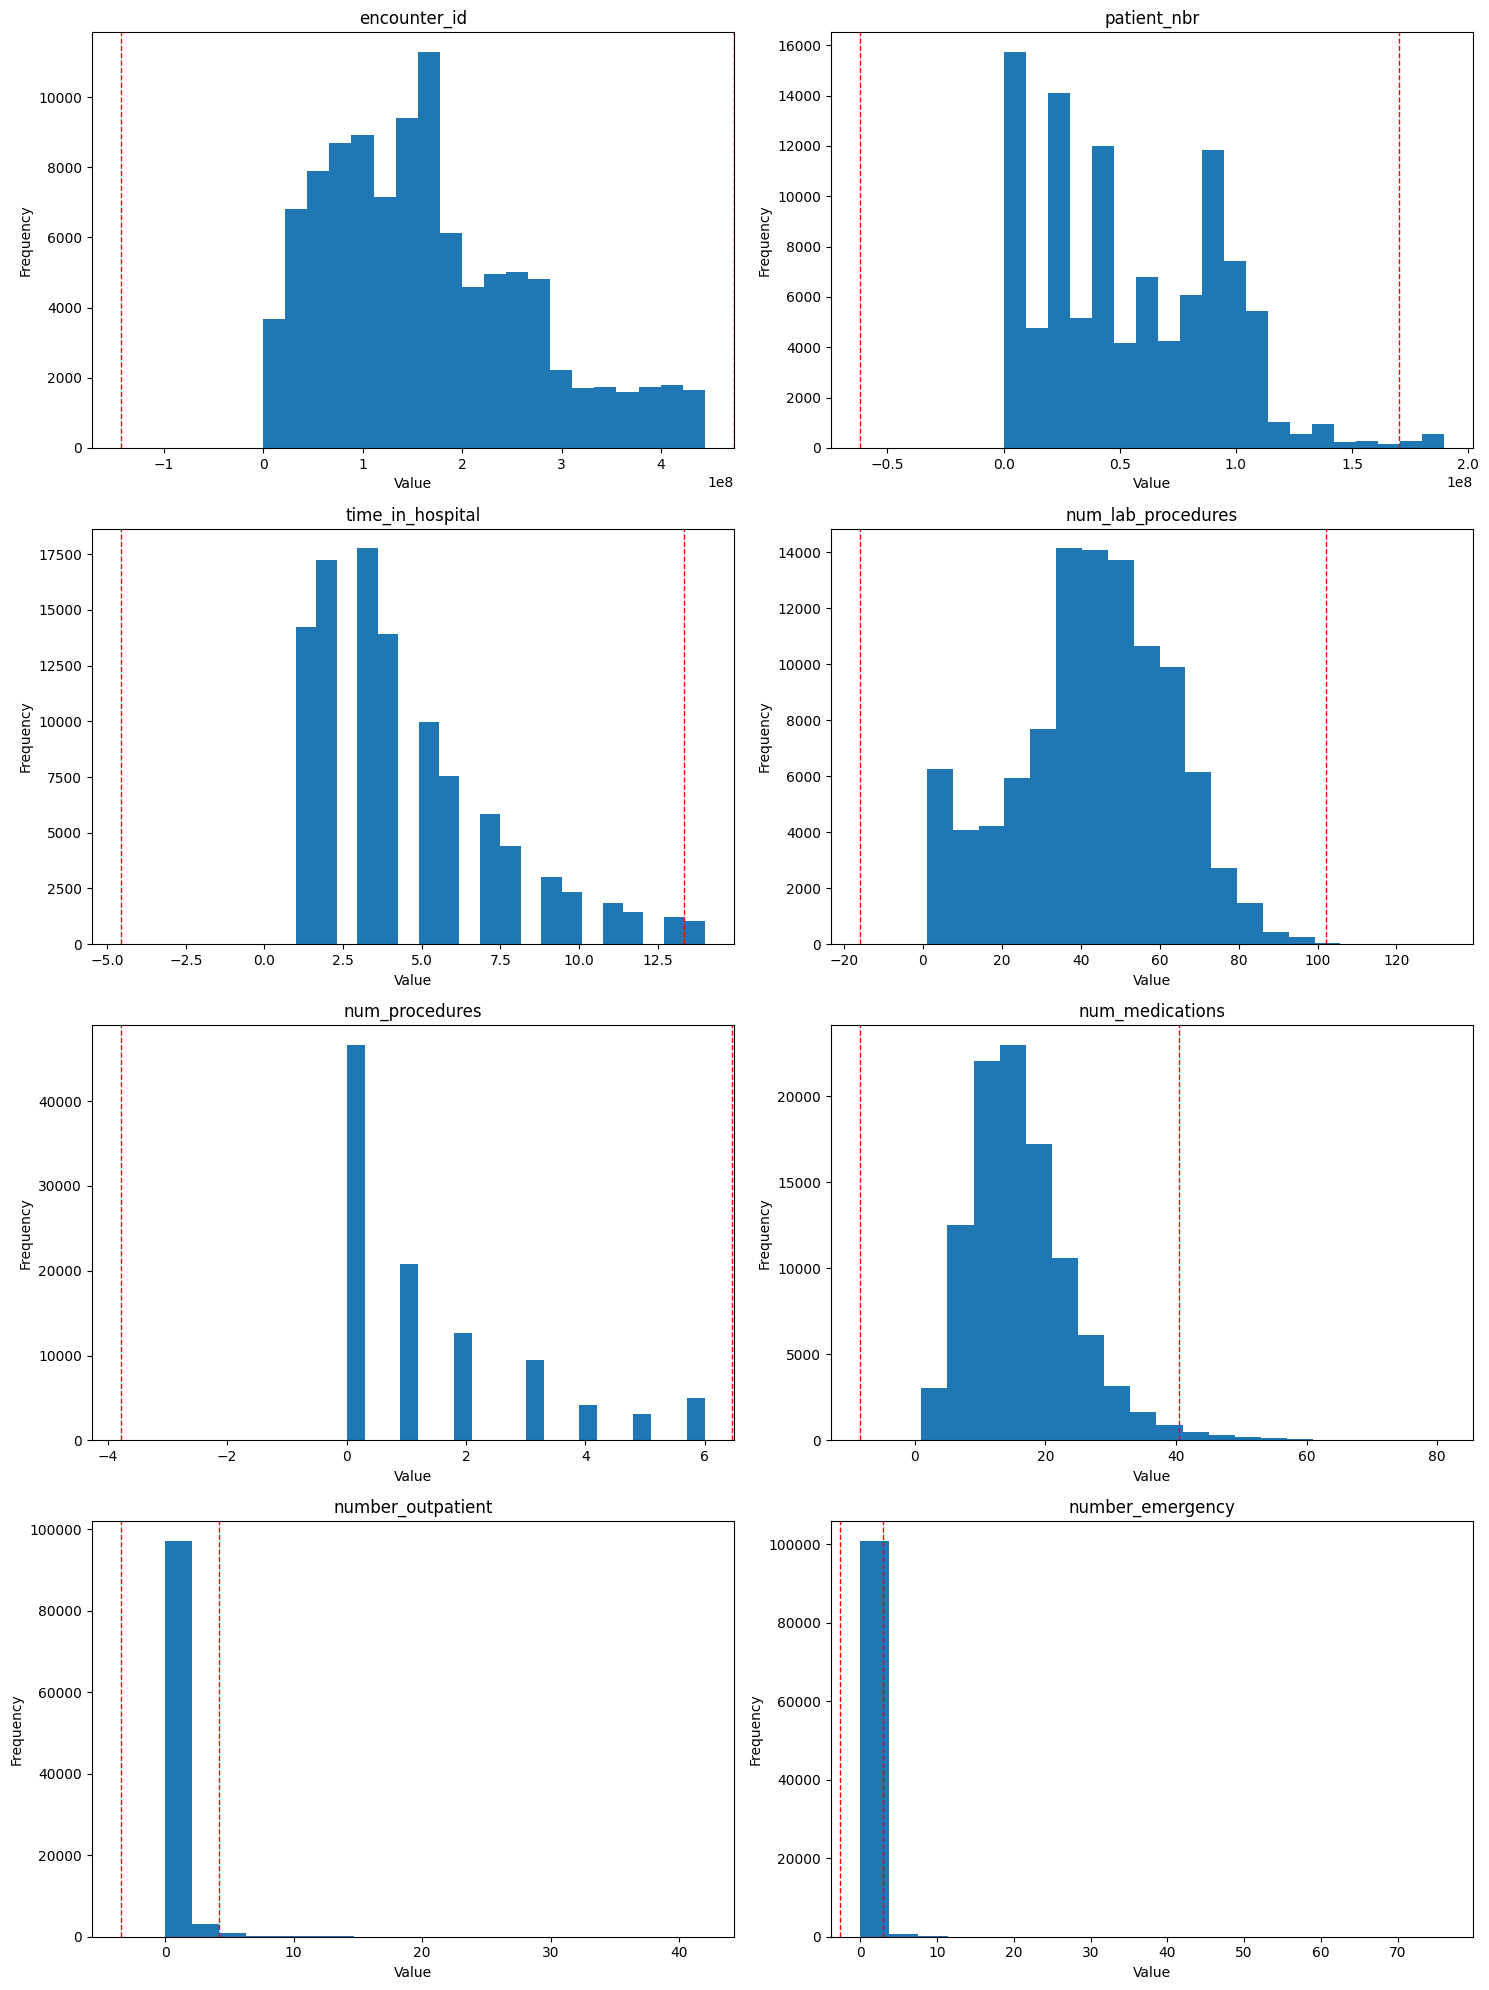

In [30]:
# Plot histogram with the upper and lower limit
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for i, ax in enumerate(axes.flatten()):
    ax.hist(df[num_features[i]], bins=20)
    # add lower and upper limits to vizualize the outlier
    ax.axvline(limit_sigma[num_features[i]][0], color='r', linestyle='dashed', linewidth=1)
    ax.axvline(limit_sigma[num_features[i]][1], color='r', linestyle='dashed', linewidth=1)
    ax.set_title(num_features[i])
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()

In [31]:
# Remove outliers from the dataframe
# Get iondex of values in the lower and upper limit
outliers = {}

for num in num_features:
  outliers = df[(df[num] <= limit_sigma[num][0]) | (df[num] >= limit_sigma[num][1])]

# Remove outliers from df

df = df.drop(outliers.index)
print(f"Total outliers removed: {len(outliers)}")

Total outliers removed: 281


### Feature Scaling

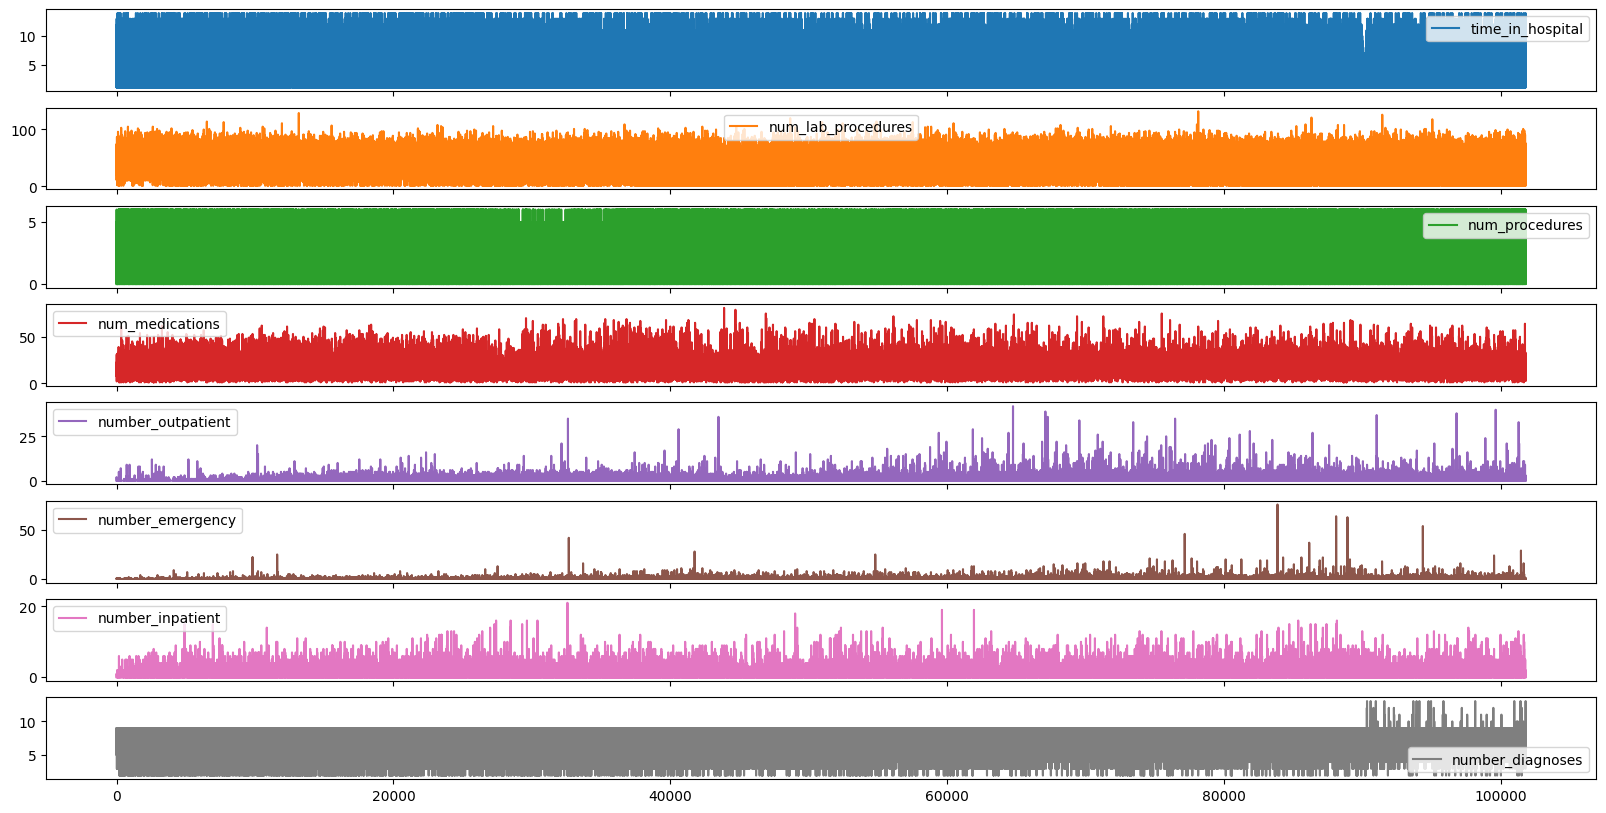

In [32]:
# Compare scales on numerical values
# change patient and encounter number to object
df[['patient_nbr', 'encounter_id']] = df[['patient_nbr', 'encounter_id']].astype('object')

num_features = df.select_dtypes(include=['int64', 'float64']).columns
df[num_features].plot(figsize=(20, 10), subplots=True)
plt.show()

**Feature Scaling Strategy**

After comparason among all the numerical variables we can see that there are some that ranges from 0 to 100, others from 0 to less than 10.
For this reason, we will be using the *Normalization (Min-Max Scaling)* which uses the min and max of each feature to scale the features.

With this approach we will keep the patterns in the data.

*Formula: (x - min) / (max - min)*

In [33]:
# Scale the numerical features using normalization
df_clean = df.copy()
for num in num_features:
  df_clean[num] = (df_clean[num] - df_clean[num].min()) / (df_clean[num].max() - df_clean[num].min())

df_clean[num_features].head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
1,0.153846,0.442748,0.000000,0.2125,0.000000,0.0,0.000000,0.636364
2,0.076923,0.076336,0.833333,0.1500,0.047619,0.0,0.047619,0.363636
3,0.076923,0.328244,0.166667,0.1875,0.000000,0.0,0.000000,0.454545
4,0.000000,0.381679,0.000000,0.0875,0.000000,0.0,0.000000,0.272727
5,0.153846,0.229008,1.000000,0.1875,0.000000,0.0,0.000000,0.636364


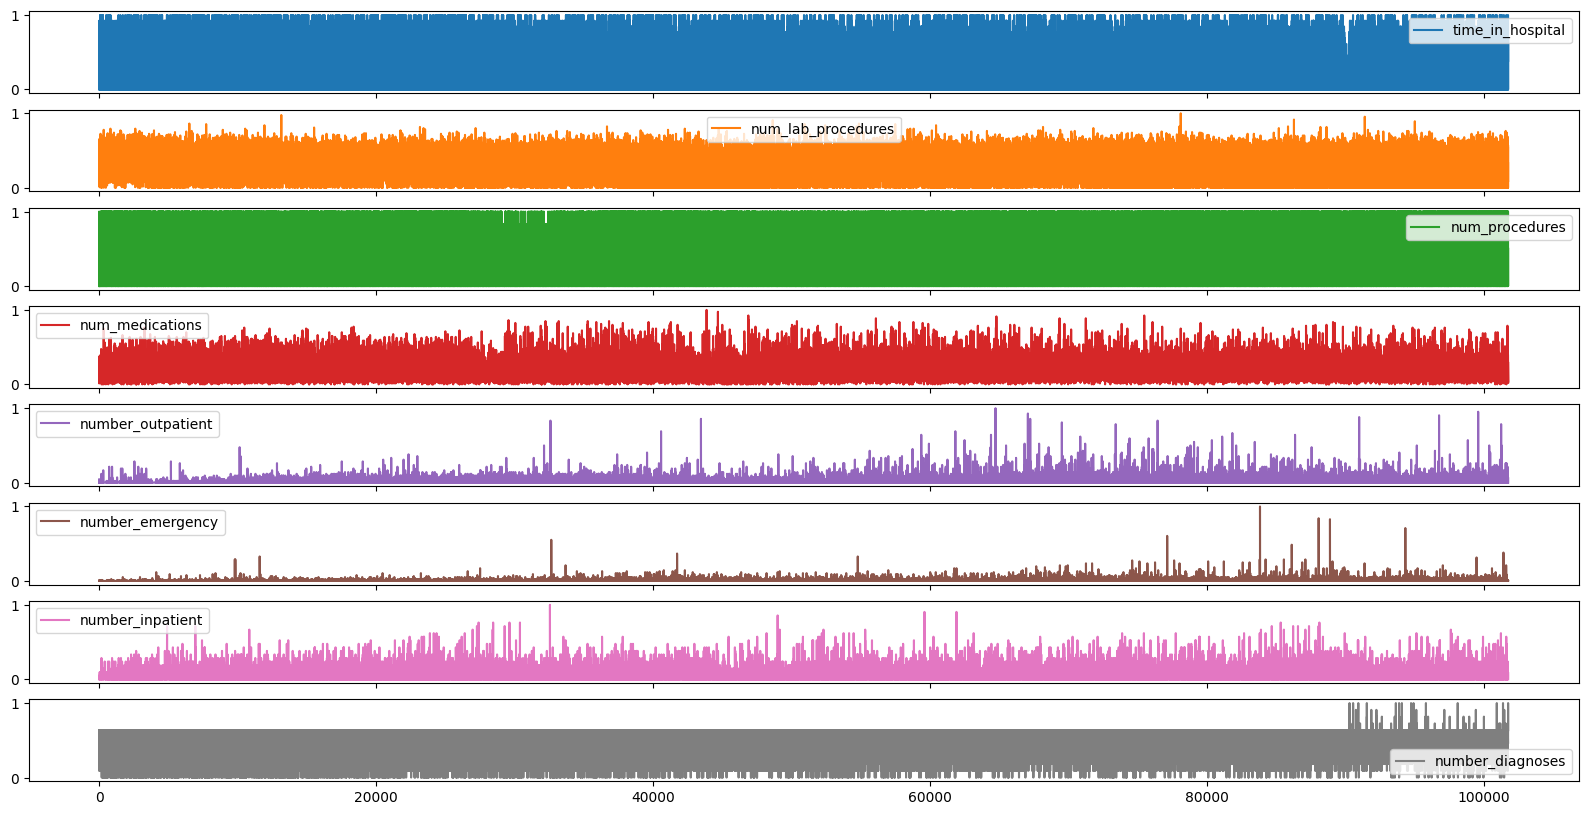

In [34]:
df_clean[num_features].plot(figsize=(20, 10), subplots=True)
plt.show()

## **4. Explore Relationships**
Now that we have a cleaned and preprocessed dataframe, we can explore the feature relationships. Specially how our Y feature "readmitted" is dependent to Categorical and Numerical variables.

We will apply:

1. ANOVA: for Readmittion to Numerical Features
1. Chi-square test: for Readmittion to Categorical Features

In [35]:
#### Relationships: Numerical Features

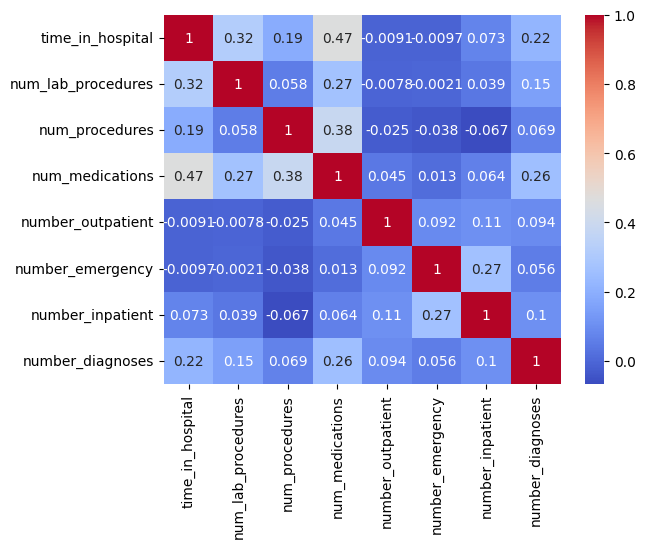

In [36]:
# Heatmap for numerical features wiht seaborn
corr = df_clean[num_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### Relationships: Numerical & Readmitted

In [37]:
# Set error to alpha 0.05
alpha = 0.05
resultAnova = []

# Iterate categorical features
for num in num_features:
  CategoryGroupList = df_clean.groupby('readmitted')[num].apply(list)
  f_value, p_value = f_oneway(*CategoryGroupList)

  # Check hypotesis using p value
  if p_value < alpha:
    resultAnova.append([num, 'Correlated', p_value, 'num'])
  else:
    resultAnova.append([num, 'Not Correlated', p_value, 'num'])

resultAnova = pd.DataFrame(resultAnova, columns=['Feature', 'Dependency', 'P-value', 'Dtype'])

In [38]:
# review the strongest correlations
resultAnova = resultAnova[resultAnova['Dependency'] == 'Correlated']
resultAnova

,Feature,Dependency,P-value,Dtype
0,time_in_hospital,Correlated,2.260988e-73,num
1,num_lab_procedures,Correlated,1.636840e-35,num
2,num_procedures,Correlated,5.401925e-47,num
3,num_medications,Correlated,8.143221e-58,num
4,number_outpatient,Correlated,1.126543e-152,num
5,number_emergency,Correlated,1.612515e-246,num
6,number_inpatient,Correlated,0.000000e+00,num
7,number_diagnoses,Correlated,4.485802e-278,num


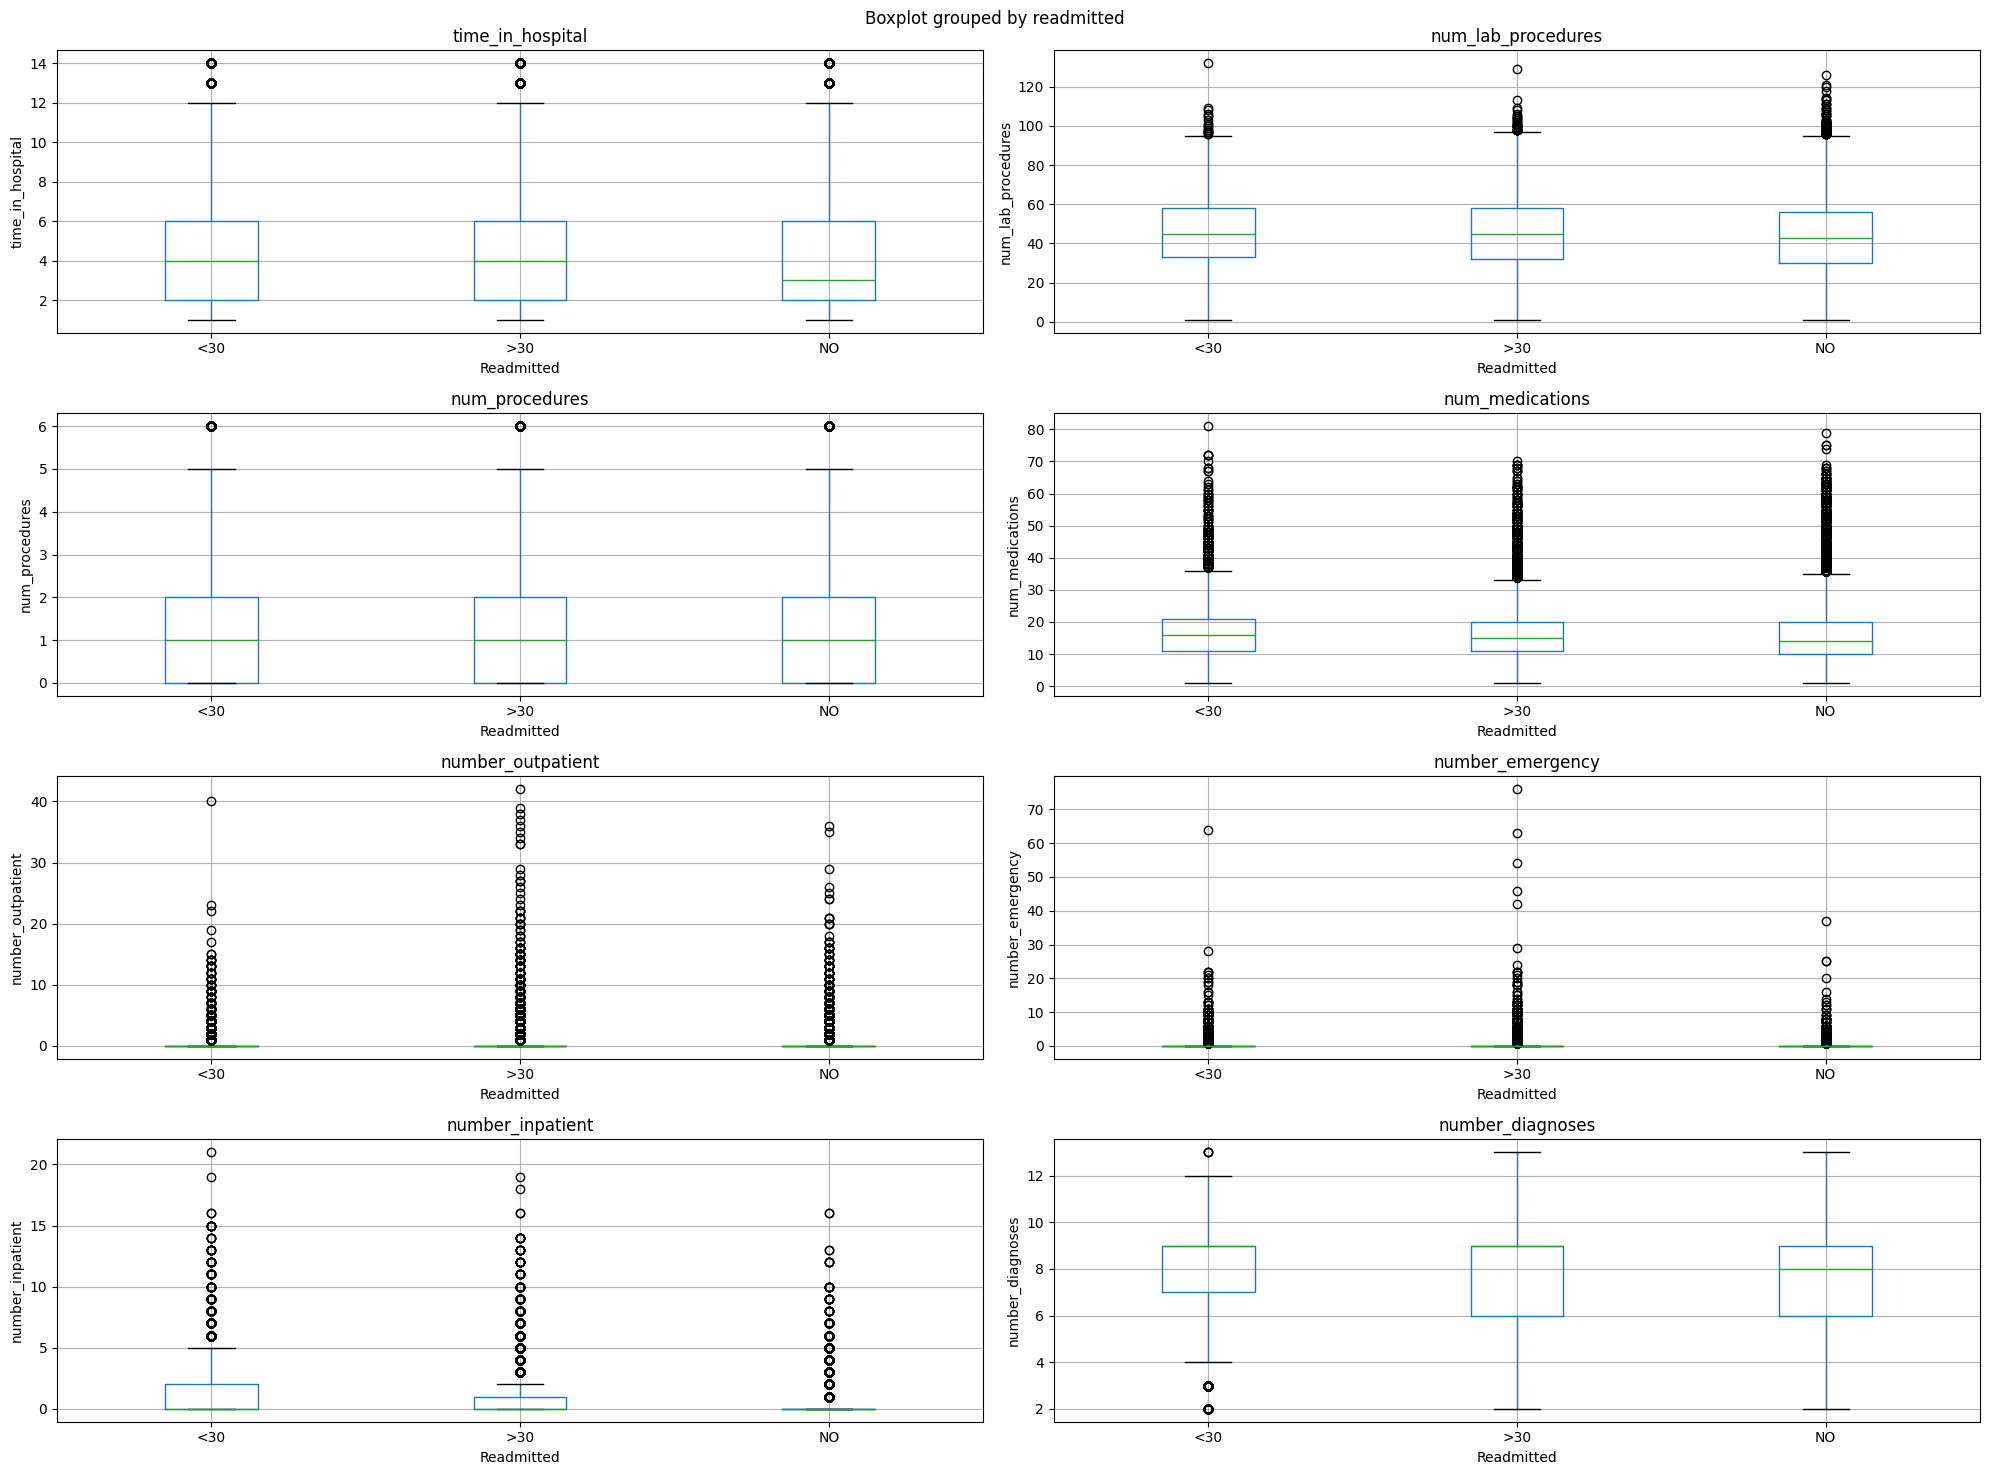

In [39]:
# Plot dependent numerical features with 'readmitted' feature
# Boxplot

fig, axes = plt.subplots(4, 2, figsize=(20, 15))

for i, ax in enumerate(axes.flatten()):
  df.boxplot(column=num_features[i], by='readmitted', ax=ax)
  ax.set_title(num_features[i])
  ax.set_xlabel('Readmitted')
  ax.set_ylabel(num_features[i])

plt.tight_layout()
plt.show()

#### Relationships: Categorical & Readmitted

In [40]:
categorical_features

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed',
       'admission_type_id_desc', 'discharge_disposition_id_desc',
       'admission_source_id_desc'],
      dtype='object')

In [41]:
# To make select the best features, we use Chi-square test.
# Null Hypothesis (H0): Two variables are independent
# Alternate Hypothesis (H1): Two variables are not independent

# Create the contingency table

resultChi2 = []
table = []
for cat in categorical_features:
    table = df[[cat,'readmitted']]
    table = pd.crosstab(table[cat], table['readmitted'])

    stat, p, dof, expected = chi2_contingency(table)

#     interpret test-statistic
    prob = 0.95

#     get critical chi-square
    critical = chi2.ppf(prob, dof)

    if abs(stat) >= critical:
        resultChi2.append([cat, 'Correlated', critical, 'cat'])
    else:
        resultChi2.append([cat, 'No Correlated', critical, 'cat'])

resultChi2 = pd.DataFrame(resultChi2, columns=['Feature', 'Dependency', 'Critical value', 'Dtype'])

resultChi2 = resultChi2.sort_values(by='Critical value', ascending=True)

In [42]:
# review the strongest correlations
resultChi2 = resultChi2[resultChi2['Dependency'] == 'Correlated']
resultChi2

,Feature,Dependency,Critical value,Dtype
34,change,Correlated,5.991465,cat
35,diabetesMed,Correlated,5.991465,cat
1,gender,Correlated,9.487729,cat
15,glimepiride,Correlated,12.591587,cat
12,repaglinide,Correlated,12.591587,cat
11,metformin,Correlated,12.591587,cat
22,acarbose,Correlated,12.591587,cat
21,rosiglitazone,Correlated,12.591587,cat
20,pioglitazone,Correlated,12.591587,cat
17,glipizide,Correlated,12.591587,cat


In [43]:
table

readmitted,<30,>30,NO
admission_source_id_desc,,,
Court/Law Enforcement,2,4,9
Emergency Room,6708,21624,28979
Extramural Birth,0,0,2
Not Available,13,16,96
Not Mapped,22,81,58
Physician Referral,3126,9628,16737
Sick Baby,0,0,1
Transfer from Ambulatory Surgery Center,0,0,2
Transfer from a Skilled Nursing Facility (SNF),101,236,518


In [49]:
print(f'total categrocial features: {len(categorical_features)}\ntotal high dependency features: {len(resultChi2)}')
print(f'total numerical features: {len(num_features)}\ntotal high dependency features: {len(resultAnova)}')

total categrocial features: 39
total high dependency features: 24
total numerical features: 8
total high dependency features: 8


#### **Conclusion of Features Relationship**

1. 61% of the cateforical features are highly correlated to the readmittions
2. 100% of the numerical features are highly correlated to the readmittions
3. No significat correlation among numerical features.

---



